library

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

analysis

In [76]:
df = pd.read_csv('../../data/processed/listing_data.csv')

In [77]:
df_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "n_unique": [df[col].nunique(dropna=False) for col in df.columns],
    "unique_values": [
        df[col].dropna().unique().tolist()
        for col in df.columns
    ]
})

df_summary

,column,dtype,n_unique,unique_values
0,listing_id,int64,266,"[506824, 1271743, 3354986, 4612134, 5842921, 6..."
1,listing_name,object,263,"[Modern Apartment in Central Hanoi, Peaceful H..."
2,listing_type,object,22,"[Entire rental unit, Private room in home, Ent..."
3,room_type,object,4,"[entire_home, private_room, hotel_room, shared..."
4,superhost,bool,2,"[True, False]"
5,latitude,float64,175,"[21.0303, 21.0511, 21.03, 21.0341, 21.019, 21...."
6,longitude,float64,185,"[105.8504, 105.8878, 105.7859, 105.8468, 105.8..."
7,guests,float64,13,"[2.0, 4.0, 5.0, 3.0, 10.0, 6.0, 9.0, 1.0, 16.0..."
8,bedrooms,float64,8,"[1.0, 2.0, 3.0, 4.0, 6.0, 5.0, 8.0, 7.0]"
9,beds,float64,11,"[1.0, 2.0, 3.0, 5.0, 6.0, 7.0, 4.0, 11.0, 8.0,..."


amennities_count,
center_mark,
guests
-> ttm_avg_rate_native

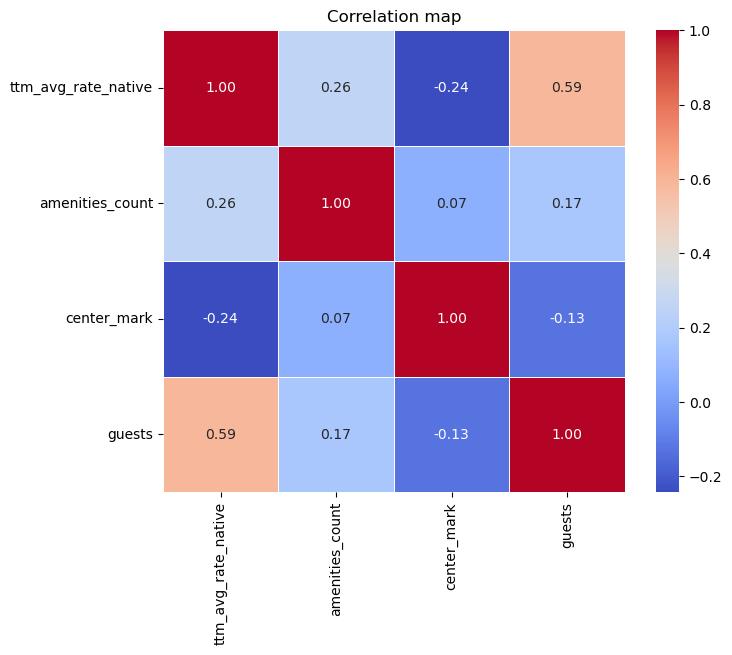

In [78]:
# Các cột muốn tính correlation
corr_cols = [
    "ttm_avg_rate_native",
    "amenities_count",
    "center_mark",
    "guests"
]

# Tạo dataframe tạm và ép kiểu numeric
df_corr = df[corr_cols].copy()

for col in corr_cols:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

# Tính correlation matrix
corr_matrix = df_corr.corr(method="spearman")

# Vẽ correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation map")
plt.show()

In [79]:
df_cluster = df.copy()

In [80]:
df_cluster["log_ttm_avg_rate_native"] = np.log1p(df_cluster["ttm_avg_rate_native"])

In [81]:
cluster_features_final = [
    "log_ttm_avg_rate_native",
    "amenities_count",
    "center_mark",
    "guests"
]

In [82]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_cluster[cluster_features_final])

In [83]:
inertias = []
silhouette_scores = {}

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

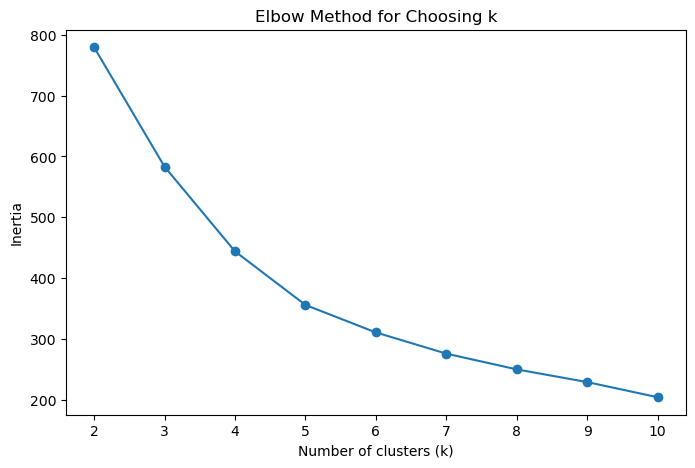

In [84]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing k")
plt.show()

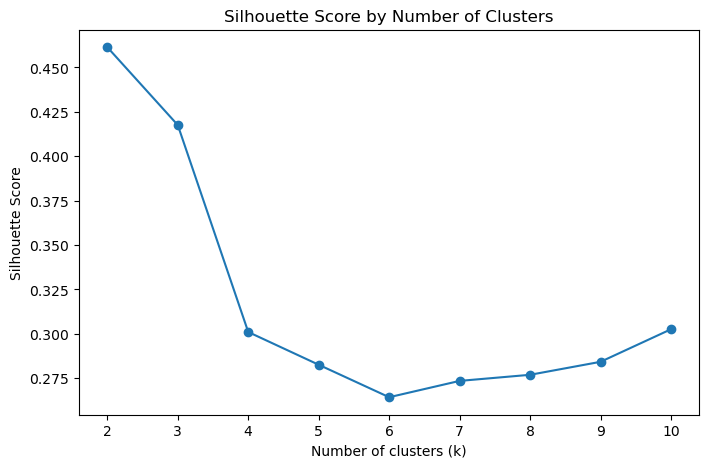

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

In [86]:
best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

In [87]:
df.loc[df_cluster.index, "market_segment"] = cluster_labels

In [88]:
df["market_segment"].value_counts().sort_index()

market_segment
0.0     82
1.0    147
2.0     32
3.0      5
Name: count, dtype: int64

In [89]:
segment_summary = df.groupby("market_segment").agg(
    listing_count=("ttm_avg_rate_native", "count"),
    avg_price=("ttm_avg_rate_native", "mean"),
    median_price=("ttm_avg_rate_native", "median"),
    avg_amenities=("amenities_count", "mean"),
    avg_center_mark=("center_mark", "mean"),
    avg_guests=("guests", "mean")
)

segment_summary.round(0)

,listing_count,avg_price,median_price,avg_amenities,avg_center_mark,avg_guests
market_segment,,,,,,
0.0,82,916621.0,783818.0,43.0,2.0,3.0
1.0,147,656452.0,624374.0,23.0,3.0,2.0
2.0,32,2473092.0,2016203.0,33.0,2.0,8.0
3.0,5,3022515.0,1750142.0,26.0,29.0,6.0
